In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import pandas as pd

os.chdir('../..')

from utils.load_datasets import OMat24Loader

/home/energy/s193624/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
train_loader = OMat24Loader(split="train")
train_df, train_counts = train_loader.get_omat24(sample_size=250000)

val_loader = OMat24Loader(split="val")
val_df, val_counts = val_loader.get_omat24(sample_size=250000)

2026-02-04 10:27:48.791 | INFO     | utils.load_datasets:_prepare_data:236 - Loaded 5300 files for split train
2026-02-04 10:27:48.793 | INFO     | utils.load_datasets:get_omat24:250 - Beginning data processing for 50000 entries.
Extracting OMat24 train Properties: 100%|██████████| 50000/50000 [00:11<00:00, 4370.56it/s]
2026-02-04 10:28:00.237 | INFO     | utils.load_datasets:get_omat24:280 - Data extraction finished. Creating DataFrame.
2026-02-04 10:28:00.279 | INFO     | utils.load_datasets:get_omat24:283 - DataFrame created with 50000 rows.
2026-02-04 10:28:00.280 | INFO     | utils.load_datasets:get_omat24:284 - Detected elements: ['Ge', 'Te', 'W', 'Ag', 'Sn', 'Cd', 'Pb', 'Cs', 'O', 'Pt', 'Ce', 'K', 'Se', 'Ga', 'H', 'Cl', 'F', 'Ti', 'Ho', 'Ni', 'N', 'Bi', 'Os', 'Pa', 'Er', 'Ir', 'Br', 'Pr', 'Si', 'Cu', 'Ac', 'Y', 'B', 'C', 'Fe', 'S', 'Th', 'Zn', 'Dy', 'Mn', 'Tm', 'Hg', 'Ru', 'Tb', 'In', 'Au', 'Mo', 'Mg', 'La', 'Ca', 'Nd', 'Zr', 'Ta', 'Pd', 'Eu', 'Sc', 'Li', 'Be', 'Tl', 'Pm', 'Hf',

/tmp/ipykernel_567292/1969323496.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset_labels, y=dataset_sizes, palette='viridis')


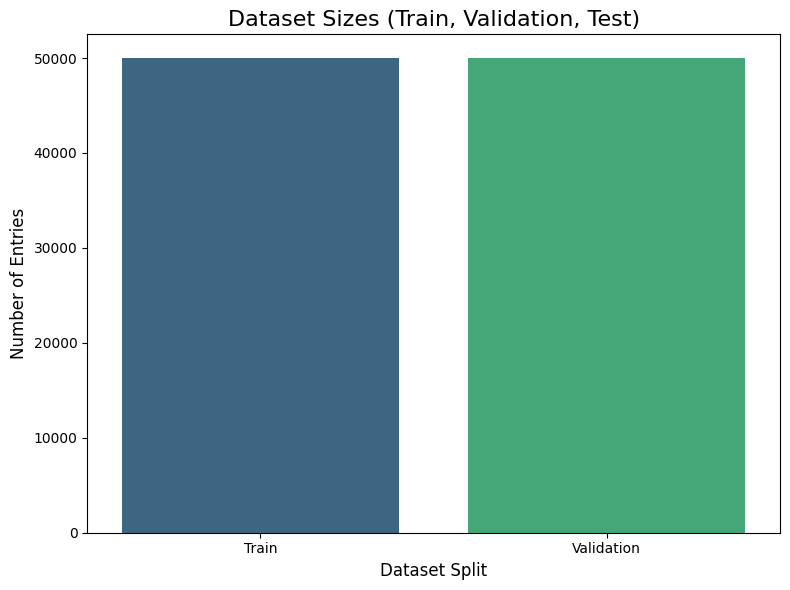

In [3]:
# Get the lengths of the DataFrames
dataset_sizes = [len(train_df), len(val_df)]

# Create labels for the datasets
dataset_labels = ['Train', 'Validation']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=dataset_labels, y=dataset_sizes, palette='viridis')

# Add title and labels
plt.title('Dataset Sizes (Train, Validation, Test)', fontsize=16)
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Number of Entries', fontsize=12)

# Add the number of entries on top of each bar
#for index, value in enumerate(dataset_sizes):
#    plt.text(index, value + 1000, str(value), ha='center', va='bottom') # Adjust offset for better visibility

plt.tight_layout()
plt.show()

In [4]:
def get_element_counts(df):
    all_symbols = [symbol for sublist in df['symbols'] for symbol in sublist]
    element_counts = collections.Counter(all_symbols)
    return pd.Series(element_counts).sort_values(ascending=False)

# Apply the function to each DataFrame
train_element_counts = get_element_counts(train_df)
val_element_counts = get_element_counts(val_df)

print("Top 10 elements in Train Dataset:")
print(train_element_counts.head(10))
print(
"\nTop 10 elements in Validation Dataset:")
print(val_element_counts.head(10))

Top 10 elements in Train Dataset:
Ge    24001
O     23856
Pt    21829
Si    19013
Ti    17120
Br    16675
Ru    13610
H      8318
F      6869
S      5965
dtype: int64

Top 10 elements in Validation Dataset:
O     23570
Se     9932
S      9854
La     8372
Pd     8347
Cl     8153
Te     8102
F      7661
Hg     7554
Ho     7190
dtype: int64


/tmp/ipykernel_567292/2058377470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_element_counts.head(10).index, y=train_element_counts.head(10).values, ax=axes[0], palette='viridis')
/tmp/ipykernel_567292/2058377470.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_element_counts.head(10).index, y=val_element_counts.head(10).values, ax=axes[1], palette='viridis')


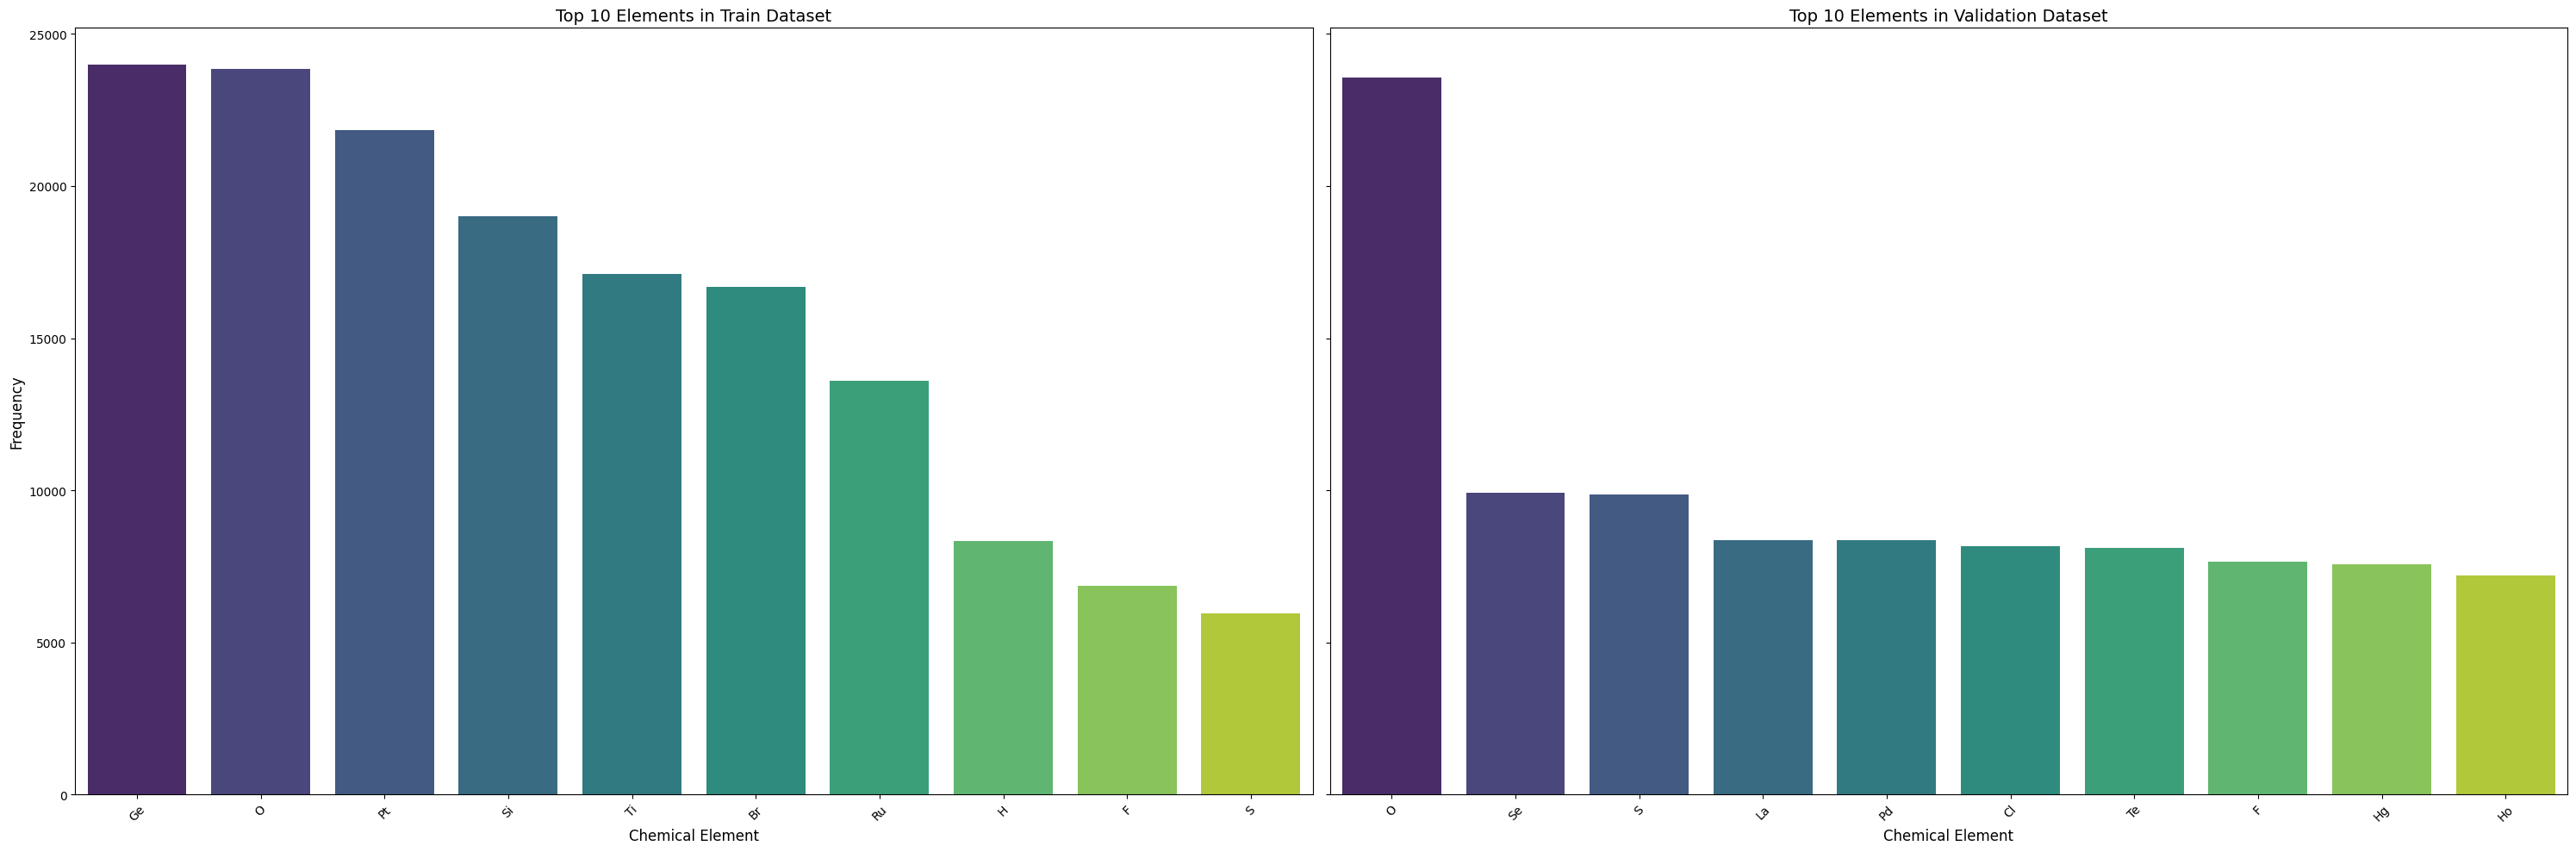

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(30, 10), sharey=True)

# Plot for Train Dataset
sns.barplot(x=train_element_counts.head(10).index, y=train_element_counts.head(10).values, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Elements in Train Dataset', fontsize=14)
axes[0].set_xlabel('Chemical Element', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot for Validation Dataset
sns.barplot(x=val_element_counts.head(10).index, y=val_element_counts.head(10).values, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Elements in Validation Dataset', fontsize=14)
axes[1].set_xlabel('Chemical Element', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Task Type Distribution in Train Dataset:
task_type
Molecular Dynamics    50000
Name: count, dtype: int64

Task Type Distribution in Validation Dataset:
task_type
Molecular Dynamics    50000
Name: count, dtype: int64


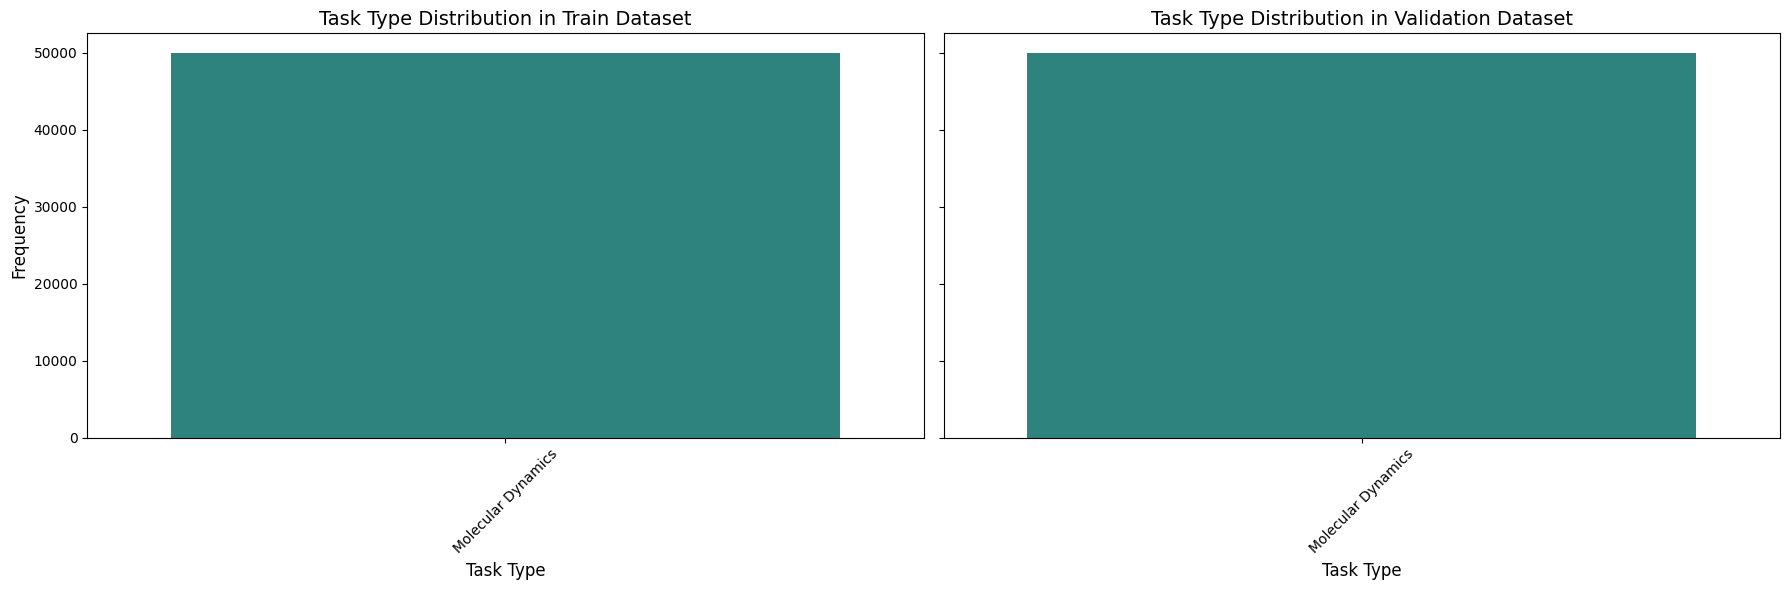

In [6]:
def get_task_type_counts(df):
    task_type_counts = df['task_type'].value_counts()
    return task_type_counts.sort_values(ascending=False)

# Apply the function to each DataFrame
train_task_type_counts = get_task_type_counts(train_df)
val_task_type_counts = get_task_type_counts(val_df)

print("Task Type Distribution in Train Dataset:")
print(train_task_type_counts)
print("\nTask Type Distribution in Validation Dataset:")
print(val_task_type_counts)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Plot for Train Dataset
sns.barplot(x=train_task_type_counts.index, y=train_task_type_counts.values, ax=axes[0], palette='viridis', hue=train_task_type_counts.index, legend=False)
axes[0].set_title('Task Type Distribution in Train Dataset', fontsize=14)
axes[0].set_xlabel('Task Type', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot for Validation Dataset
sns.barplot(x=val_task_type_counts.index, y=val_task_type_counts.values, ax=axes[1], palette='viridis', hue=val_task_type_counts.index, legend=False)
axes[1].set_title('Task Type Distribution in Validation Dataset', fontsize=14)
axes[1].set_xlabel('Task Type', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
print("Descriptive statistics for 'energy_corrected_mp2020' in Train Dataset:")
print(train_df['energy_corrected_mp2020'].describe())

print("\nDescriptive statistics for 'energy_corrected_mp2020' in Validation Dataset:")
print(val_df['energy_corrected_mp2020'].describe())

Descriptive statistics for 'energy_corrected_mp2020' in Train Dataset:
count    48957.000000
mean       -45.404523
std         23.808813
min       -168.865002
25%        -53.127141
50%        -38.852415
75%        -29.133873
max         33.454579
Name: energy_corrected_mp2020, dtype: float64

Descriptive statistics for 'energy_corrected_mp2020' in Validation Dataset:
count    48511.000000
mean       -42.721199
std         38.771946
min       -780.253801
25%        -54.628062
50%        -30.349674
75%        -19.274849
max         30.810899
Name: energy_corrected_mp2020, dtype: float64


/tmp/ipykernel_567292/158263912.py:17: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


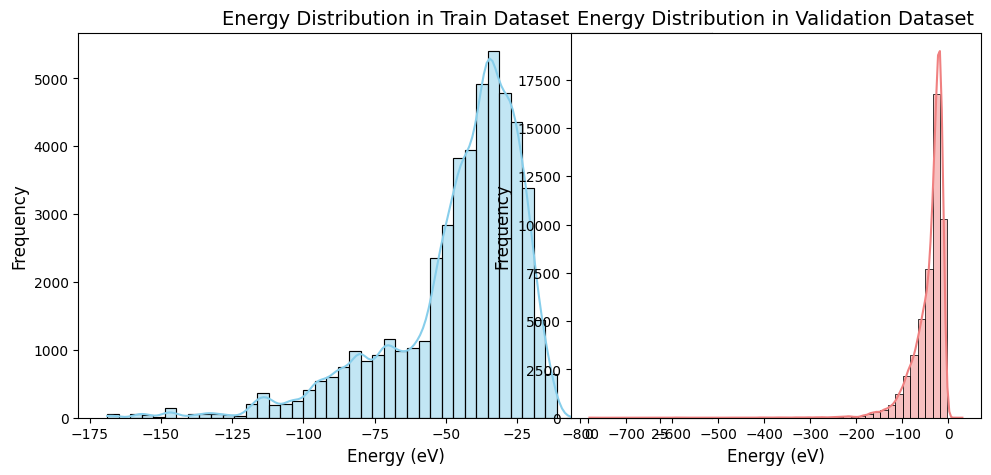

In [8]:
plt.figure(figsize=(18, 5))

# Plot for Train Dataset
plt.subplot(1, 2, 1)
sns.histplot(train_df['energy_corrected_mp2020'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Energy Distribution in Train Dataset', fontsize=14)
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot for Validation Dataset
plt.subplot(1, 3, 2)
sns.histplot(val_df['energy_corrected_mp2020'].dropna(), bins=50, kde=True, color='lightcoral')
plt.title('Energy Distribution in Validation Dataset', fontsize=14)
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Dataset Sizes:** The `train` dataset is substantially larger with 1,009,850 entries, followed by the `validation` dataset with 107,732 entries, and the `test` dataset with 53,727 entries.
*   **Element Distribution:**
    *   The `train` and `validation` datasets show similar top 10 elemental compositions, heavily featuring O, Se, S, Te, and Li.
    *   The `test` dataset, however, exhibits a notably different top 10 composition, including elements like Al, In, Si, Ga, Ge, Cu, and Ni, which are less prominent in the other two sets. This suggests potential differences in material compositions represented in the test set.
*   **Calculation ID Distribution:** All three datasets (`train`, `validation`, and `test`) show a consistent pattern in their most frequent `calc_id` types. The top IDs across all splits are predominantly `aimd-from-PBE-1000-npt`, `aimd-from-PBE-1000-nvt`, `rattled-1000`, and `rattled-relax`.
*   **Task Type Distribution:** The distribution of `task_type` is remarkably consistent across all splits. 'Molecular Dynamics' is the most frequent type (e.g., 551,373 in train), followed by 'Static' (e.g., 357,934 in train), and then 'Structure Optimization' (e.g., 100,543 in train), maintaining similar proportions in validation and test sets.
*   **Prototype Label Distribution:** The distribution of `prototype_label` varies significantly across the splits. The `train` dataset shows a few highly dominant prototype labels (e.g., `AB_aP12_1_6a_6a:B-C` with 194 occurrences), whereas the `validation` and `test` datasets exhibit a flatter distribution for their top labels, indicating a broader range of less frequently repeated prototypes in these sets.
*   **Energy Distribution:** The `energy_corrected_mp2020` distributions across all three datasets (train, validation, test) are visually similar, characterized by a primary peak and a general spread of energy values. The descriptive statistics show comparable means (e.g., train: -84.42 eV, val: -85.20 eV, test: -91.19 eV) and standard deviations (e.g., train: 106.45 eV, val: 106.95 eV, test: 114.82 eV).

### Insights or Next Steps

*   **Address Test Set Discrepancy:** The significant difference in the top elemental composition and prototype label distribution of the `test` set compared to `train` and `validation` sets warrants further investigation. This could impact model generalization performance if the `test` set contains novel chemical environments not adequately represented in the training data. Consider techniques like stratified sampling for future dataset splits to ensure better representation of diverse elements and prototypes.
*   **Leverage Consistent Task/Calc Types:** The consistent distribution of `calc_id` and `task_type` across all datasets is a positive characteristic, suggesting that models trained on this data should be exposed to similar types of calculations and tasks during evaluation.
